# Exercise 3

In [143]:
import pandas as pd

In [148]:
df = pd.read_csv("Data/forecast_data_3years.csv",encoding='unicode_escape',sep=';')

In [149]:
df

,mois,Spend,Conversions,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,juin-15,"39456,23",1578,NaN,NaN,NaN,NaN,NaN,NaN
1,juil-15,"57338,93",1864,NaN,NaN,NaN,NaN,NaN,NaN
2,août-15,"31802,36",1138,NaN,NaN,NaN,NaN,NaN,NaN
3,sept-15,"52195,88",2176,NaN,NaN,NaN,NaN,NaN,NaN
4,oct-15,"27642,56",1185,NaN,NaN,NaN,NaN,NaN,NaN
5,nov-15,"31215,6",1471,NaN,NaN,NaN,NaN,NaN,NaN
6,déc-15,"64036,93",2942,NaN,NaN,NaN,NaN,NaN,NaN
7,janv-16,"58342,15",2768,NaN,NaN,NaN,NaN,NaN,NaN
8,févr-16,"18326,47",863,NaN,NaN,NaN,NaN,NaN,NaN
9,mars-16,"90135,24",3127,NaN,NaN,NaN,NaN,NaN,NaN


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mois         36 non-null     object 
 1   Spend        36 non-null     object 
 2   Conversions  36 non-null     int64  
 3   Unnamed: 3   0 non-null      float64
 4   Unnamed: 4   0 non-null      float64
 5   Unnamed: 5   0 non-null      float64
 6   Unnamed: 6   0 non-null      float64
 7   Unnamed: 7   0 non-null      float64
 8   Unnamed: 8   0 non-null      float64
dtypes: float64(6), int64(1), object(2)
memory usage: 2.7+ KB


In [151]:
df = df[['mois','Spend','Conversions']]

In [152]:
df

,mois,Spend,Conversions
0,juin-15,"39456,23",1578
1,juil-15,"57338,93",1864
2,août-15,"31802,36",1138
3,sept-15,"52195,88",2176
4,oct-15,"27642,56",1185
5,nov-15,"31215,6",1471
6,déc-15,"64036,93",2942
7,janv-16,"58342,15",2768
8,févr-16,"18326,47",863
9,mars-16,"90135,24",3127


In [154]:
df['Spend'] = df['Spend'].replace({',':'.'}, regex=True)


/var/folders/d7/5lnxp9g912g0c9nbw2ynhg5m0000gn/T/ipykernel_10213/960071396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Spend'] = df['Spend'].replace({',':'.'}, regex=True)


In [155]:
df['Conversions'] = pd.to_numeric(df['Conversions'])
df['Spend'] = pd.to_numeric(df['Spend'])


/var/folders/d7/5lnxp9g912g0c9nbw2ynhg5m0000gn/T/ipykernel_10213/2956537525.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Conversions'] = pd.to_numeric(df['Conversions'])
/var/folders/d7/5lnxp9g912g0c9nbw2ynhg5m0000gn/T/ipykernel_10213/2956537525.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Spend'] = pd.to_numeric(df['Spend'])


In [156]:
df

,mois,Spend,Conversions
0,juin-15,39456.23,1578
1,juil-15,57338.93,1864
2,août-15,31802.36,1138
3,sept-15,52195.88,2176
4,oct-15,27642.56,1185
5,nov-15,31215.60,1471
6,déc-15,64036.93,2942
7,janv-16,58342.15,2768
8,févr-16,18326.47,863
9,mars-16,90135.24,3127


In [157]:
# df = df.reset_index()

In [162]:
df.dtypes

mois            object
Spend          float64
Conversions      int64
dtype: object

In [ ]:
spend = df['M']
conversions = df['conversions']

# Plotting using matplotlib and seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x=spend, y=conversions, color='blue', alpha=0.7)
plt.title('Spend vs Conversions')
plt.xlabel('Spend')
plt.ylabel('Conversions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [158]:
# df[['Date', 'Spend']] = df['index'].str.split(';', expand=True)

In [159]:
# df = df.rename(columns={'mois;Spend;Conversions;;;;;;': 'Conversions'})

In [160]:
# df['Conversions_l'] = df['Conversions'].replace({';':''}, regex=True)
# del df['index']


In [161]:
# df['Conversions_l'] = pd.to_numeric(df['Conversions_l'])
# df['Spend'] = pd.to_numeric(df['Spend'])
# df.dtypes

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

In [164]:
# Extract relevant columns
X = df['Spend'].values.reshape(-1, 1)  # independent variable: Spend
y = df['Conversions'].values          # dependent variable: Conversions

In [165]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [166]:
# Initialize regressors
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regression': xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
}


In [167]:
# Train and evaluate models
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f'Model: {name}')
    print(f'R-squared: {r2:.2f}')
    print(f'Mean Squared Error: {mse:.2f}')
    print('------------------------------------------')


Model: Linear Regression
R-squared: -3.44
Mean Squared Error: 1032315.52
------------------------------------------
Model: Ridge Regression
R-squared: -3.44
Mean Squared Error: 1032315.52
------------------------------------------
Model: Lasso Regression
R-squared: -3.44
Mean Squared Error: 1032315.40
------------------------------------------
Model: Decision Tree Regression
R-squared: -4.16
Mean Squared Error: 1198336.88
------------------------------------------
Model: Random Forest Regression
R-squared: -1.90
Mean Squared Error: 673602.83
------------------------------------------
Model: XGBoost Regression
R-squared: -4.15
Mean Squared Error: 1197645.12
------------------------------------------


## Alternate data synthesis

In [86]:
df['conversions'] = df['Conversions'].str.strip(';')

In [87]:
df['conversions'] = df['conversions'].replace({';':'.'}, regex=True)
df

,Conversions,Date,Spend,Conversions_l,conversions
0,23;1578;;;;;;,juin-15,39456,231578,23.1578
1,93;1864;;;;;;,juil-15,57338,931864,93.1864
2,36;1138;;;;;;,août-15,31802,361138,36.1138
3,88;2176;;;;;;,sept-15,52195,882176,88.2176
4,56;1185;;;;;;,oct-15,27642,561185,56.1185
5,6;1471;;;;;;,nov-15,31215,61471,6.1471
6,93;2942;;;;;;,déc-15,64036,932942,93.2942
7,15;2768;;;;;;,janv-16,58342,152768,15.2768
8,47;863;;;;;;,févr-16,18326,47863,47.863
9,24;3127;;;;;;,mars-16,90135,243127,24.3127


In [88]:
df['conversions'] = pd.to_numeric(df['conversions'])
df['Spend'] = pd.to_numeric(df['Spend'])
df.dtypes

Conversions       object
Date              object
Spend              int64
Conversions_l      int64
conversions      float64
dtype: object

In [89]:
df['conversions']

0     23.1578
1     93.1864
2     36.1138
3     88.2176
4     56.1185
5      6.1471
6     93.2942
7     15.2768
8     47.8630
9     24.3127
10     1.1412
11    12.1819
12    89.2003
13    63.2423
14    75.1645
15    35.1758
16    56.2015
17    22.2907
18    85.3503
19    37.3381
20     3.1300
21    32.1926
22    61.1601
23    57.1160
24    31.2373
25    24.2097
26    64.6530
27    94.8880
28    99.1286
29     9.4071
30    16.1893
31    38.2041
32     1.1146
33     4.2127
34    12.4310
35    46.1792
Name: conversions, dtype: float64

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

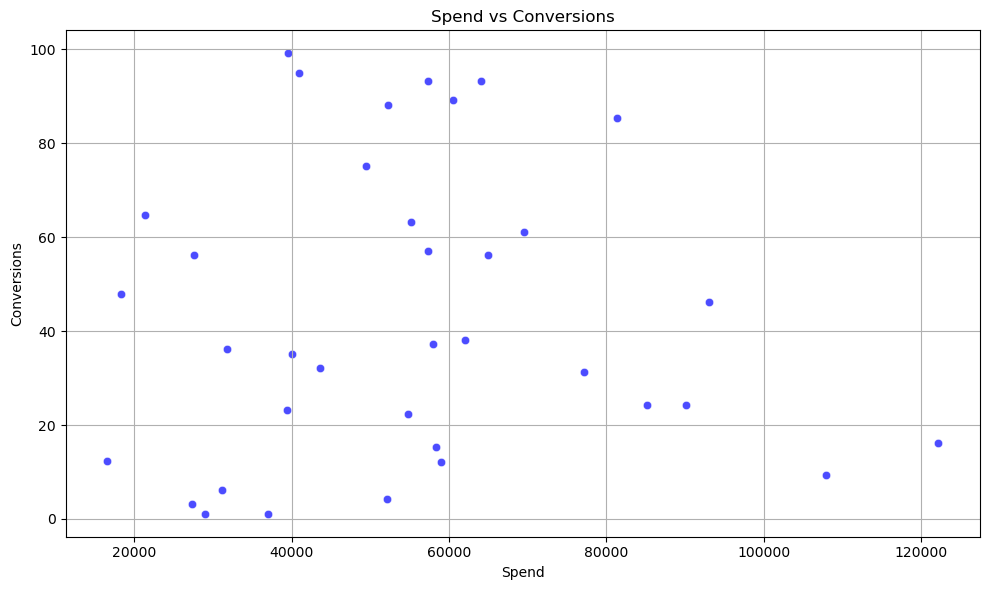

In [91]:
spend = df['Spend']
conversions = df['conversions']

# Plotting using matplotlib and seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x=spend, y=conversions, color='blue', alpha=0.7)
plt.title('Spend vs Conversions')
plt.xlabel('Spend')
plt.ylabel('Conversions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [92]:
# Extract relevant columns
X = df['Spend'].values.reshape(-1, 1)  # independent variable: Spend
y = df['conversions'].values          # dependent variable: Conversions

In [93]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [94]:
# Initialize regressors
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regression': xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
}


In [95]:
# Train and evaluate models
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    print(f'Model: {name}')
    print(f'R-squared: {r2:.2f}')
    print(f'Mean Squared Error: {mse:.2f}')
    print('------------------------------------------')


Model: Linear Regression
R-squared: -0.34
Mean Squared Error: 598.64
------------------------------------------
Model: Ridge Regression
R-squared: -0.34
Mean Squared Error: 598.64
------------------------------------------
Model: Lasso Regression
R-squared: -0.34
Mean Squared Error: 598.64
------------------------------------------
Model: Decision Tree Regression
R-squared: -3.69
Mean Squared Error: 2094.55
------------------------------------------
Model: Random Forest Regression
R-squared: -1.94
Mean Squared Error: 1314.79
------------------------------------------
Model: XGBoost Regression
R-squared: -3.69
Mean Squared Error: 2093.89
------------------------------------------


### Sales Forecasting

In [99]:
from googletrans import Translator

In [100]:
translator = Translator()


In [101]:
# Define a safe translation function to handle exceptions
def safe_translate(date_text):
    try:
        # Ensure the text is a string
        if not isinstance(date_text, str):
            date_text = str(date_text)
        # Perform the translation
        translated = translator.translate(date_text, src='fr', dest='en')
        return translated.text
    except Exception as e:
        print(f"Error translating {date_text}: {e}")
        return None

In [102]:
df['Date_trans'] = df['Date'].apply(safe_translate)


In [103]:
df

,Conversions,Date,Spend,Conversions_l,conversions,Date_trans
0,23;1578;;;;;;,juin-15,39456,231578,23.1578,June-15
1,93;1864;;;;;;,juil-15,57338,931864,93.1864,Jul-15
2,36;1138;;;;;;,août-15,31802,361138,36.1138,August-15
3,88;2176;;;;;;,sept-15,52195,882176,88.2176,Sept-15
4,56;1185;;;;;;,oct-15,27642,561185,56.1185,Oct -15
5,6;1471;;;;;;,nov-15,31215,61471,6.1471,Nov-15
6,93;2942;;;;;;,déc-15,64036,932942,93.2942,Dec-15
7,15;2768;;;;;;,janv-16,58342,152768,15.2768,Jan-16
8,47;863;;;;;;,févr-16,18326,47863,47.8630,Feb-16
9,24;3127;;;;;;,mars-16,90135,243127,24.3127,March-16


In [106]:
df = df.replace('Feb.', 'Feb- 17')

In [107]:
df

,Conversions,Date,Spend,Conversions_l,conversions,Date_trans
0,23;1578;;;;;;,juin-15,39456,231578,23.1578,June-15
1,93;1864;;;;;;,juil-15,57338,931864,93.1864,Jul-15
2,36;1138;;;;;;,août-15,31802,361138,36.1138,August-15
3,88;2176;;;;;;,sept-15,52195,882176,88.2176,Sept-15
4,56;1185;;;;;;,oct-15,27642,561185,56.1185,Oct -15
5,6;1471;;;;;;,nov-15,31215,61471,6.1471,Nov-15
6,93;2942;;;;;;,déc-15,64036,932942,93.2942,Dec-15
7,15;2768;;;;;;,janv-16,58342,152768,15.2768,Jan-16
8,47;863;;;;;;,févr-16,18326,47863,47.8630,Feb-16
9,24;3127;;;;;;,mars-16,90135,243127,24.3127,March-16


In [108]:
df[['Month', 'Year']] = df['Date_trans'].str.split('-', expand=True)


In [109]:
df

,Conversions,Date,Spend,Conversions_l,conversions,Date_trans,Month,Year
0,23;1578;;;;;;,juin-15,39456,231578,23.1578,June-15,June,15
1,93;1864;;;;;;,juil-15,57338,931864,93.1864,Jul-15,Jul,15
2,36;1138;;;;;;,août-15,31802,361138,36.1138,August-15,August,15
3,88;2176;;;;;;,sept-15,52195,882176,88.2176,Sept-15,Sept,15
4,56;1185;;;;;;,oct-15,27642,561185,56.1185,Oct -15,Oct,15
5,6;1471;;;;;;,nov-15,31215,61471,6.1471,Nov-15,Nov,15
6,93;2942;;;;;;,déc-15,64036,932942,93.2942,Dec-15,Dec,15
7,15;2768;;;;;;,janv-16,58342,152768,15.2768,Jan-16,Jan,16
8,47;863;;;;;;,févr-16,18326,47863,47.8630,Feb-16,Feb,16
9,24;3127;;;;;;,mars-16,90135,243127,24.3127,March-16,March,16


In [111]:
month_map = {
    'Jan': 1, 'Feb': 2, 'March': 3, 'Apr': 4, 'May': 5, 'June': 6,
    'Jul': 7, 'August': 8, 'Sept': 9, 'Oct ': 10, 'Nov': 11, 'Dec': 12
}

# Replace month names with numerical values
df['Month'] = df['Month'].map(month_map)

In [112]:
df

,Conversions,Date,Spend,Conversions_l,conversions,Date_trans,Month,Year
0,23;1578;;;;;;,juin-15,39456,231578,23.1578,June-15,6.0,15
1,93;1864;;;;;;,juil-15,57338,931864,93.1864,Jul-15,7.0,15
2,36;1138;;;;;;,août-15,31802,361138,36.1138,August-15,8.0,15
3,88;2176;;;;;;,sept-15,52195,882176,88.2176,Sept-15,9.0,15
4,56;1185;;;;;;,oct-15,27642,561185,56.1185,Oct -15,10.0,15
5,6;1471;;;;;;,nov-15,31215,61471,6.1471,Nov-15,11.0,15
6,93;2942;;;;;;,déc-15,64036,932942,93.2942,Dec-15,12.0,15
7,15;2768;;;;;;,janv-16,58342,152768,15.2768,Jan-16,1.0,16
8,47;863;;;;;;,févr-16,18326,47863,47.8630,Feb-16,2.0,16
9,24;3127;;;;;;,mars-16,90135,243127,24.3127,March-16,3.0,16


In [113]:
df.loc[df.Spend==65003, 'Month'] = 10
df

,Conversions,Date,Spend,Conversions_l,conversions,Date_trans,Month,Year
0,23;1578;;;;;;,juin-15,39456,231578,23.1578,June-15,6.0,15
1,93;1864;;;;;;,juil-15,57338,931864,93.1864,Jul-15,7.0,15
2,36;1138;;;;;;,août-15,31802,361138,36.1138,August-15,8.0,15
3,88;2176;;;;;;,sept-15,52195,882176,88.2176,Sept-15,9.0,15
4,56;1185;;;;;;,oct-15,27642,561185,56.1185,Oct -15,10.0,15
5,6;1471;;;;;;,nov-15,31215,61471,6.1471,Nov-15,11.0,15
6,93;2942;;;;;;,déc-15,64036,932942,93.2942,Dec-15,12.0,15
7,15;2768;;;;;;,janv-16,58342,152768,15.2768,Jan-16,1.0,16
8,47;863;;;;;;,févr-16,18326,47863,47.8630,Feb-16,2.0,16
9,24;3127;;;;;;,mars-16,90135,243127,24.3127,March-16,3.0,16


In [114]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [115]:
df['Month'] = df['Month'].astype(int)

In [116]:
df.dtypes

Conversions       object
Date              object
Spend              int64
Conversions_l      int64
conversions      float64
Date_trans        object
Month              int64
Year               int64
dtype: object

In [118]:
df['Date'] = df['Month'].astype(str) + '/1/' + df['Year'].astype(str)

# Convert to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')

In [119]:
df

,Conversions,Date,Spend,Conversions_l,conversions,Date_trans,Month,Year
0,23;1578;;;;;;,2015-06-01,39456,231578,23.1578,June-15,6,15
1,93;1864;;;;;;,2015-07-01,57338,931864,93.1864,Jul-15,7,15
2,36;1138;;;;;;,2015-08-01,31802,361138,36.1138,August-15,8,15
3,88;2176;;;;;;,2015-09-01,52195,882176,88.2176,Sept-15,9,15
4,56;1185;;;;;;,2015-10-01,27642,561185,56.1185,Oct -15,10,15
5,6;1471;;;;;;,2015-11-01,31215,61471,6.1471,Nov-15,11,15
6,93;2942;;;;;;,2015-12-01,64036,932942,93.2942,Dec-15,12,15
7,15;2768;;;;;;,2016-01-01,58342,152768,15.2768,Jan-16,1,16
8,47;863;;;;;;,2016-02-01,18326,47863,47.8630,Feb-16,2,16
9,24;3127;;;;;;,2016-03-01,90135,243127,24.3127,March-16,3,16


In [131]:
trend_df = df[['Conversions_l','Date']]

In [132]:
trend_df = trend_df.set_index('Date')


<Axes: xlabel='Date'>

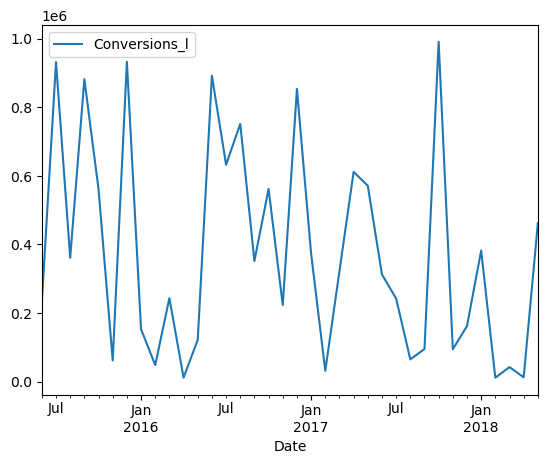

In [133]:
trend_df.plot.line()

In [138]:
from statsmodels.tsa.arima.model import ARIMA

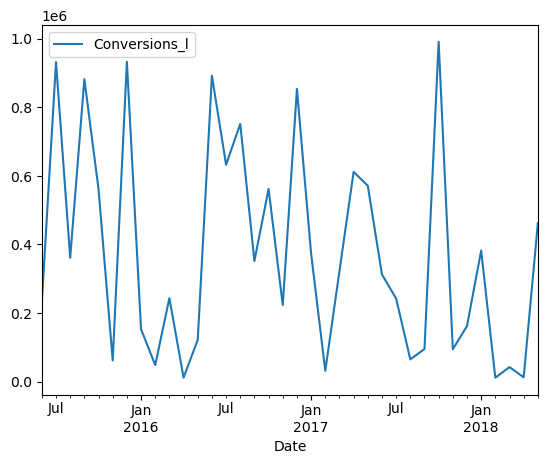

In [136]:
# Plot the data
trend_df.plot()
plt.show()

In [139]:
# Fit the ARIMA model
model = ARIMA(trend_df, order=(5, 1, 0))
model_fit = model.fit()

/Users/mohammedjawhar/anaconda3/envs/madc/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mohammedjawhar/anaconda3/envs/madc/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mohammedjawhar/anaconda3/envs/madc/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [140]:
# Summary of the model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          Conversions_l   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -494.831
Date:                Tue, 18 Jun 2024   AIC                           1001.662
Time:                        19:09:06   BIC                           1010.994
Sample:                    06-01-2015   HQIC                          1004.883
                         - 05-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8136      0.171     -4.754      0.000      -1.149      -0.478
ar.L2         -0.6709      0.194     -3.456      0.001      -1.051      -0.290
ar.L3         -0.4215      0.256     -1.648      0.0

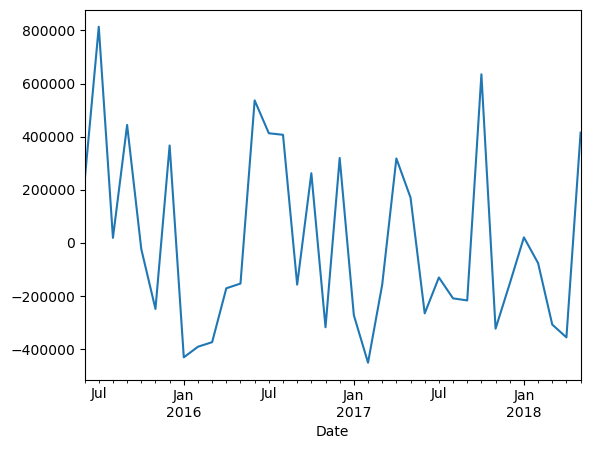

In [141]:
# Plot the residuals
residuals = model_fit.resid
residuals.plot()
plt.show()

In [142]:
# Forecast future values
forecast = model_fit.forecast(steps=12)
print(forecast)

2018-06-01    229358.919467
2018-07-01    208741.685278
2018-08-01    198748.715764
2018-09-01    105275.648603
2018-10-01    196580.756133
2018-11-01    258550.810872
2018-12-01    196439.385537
2019-01-01    215422.944643
2019-02-01    194431.326811
2019-03-01    171228.602493
2019-04-01    210949.636936
2019-05-01    209529.880297
Freq: MS, Name: predicted_mean, dtype: float64


In [134]:
from statsmodels.tsa.stattools import adfuller


In [135]:
X = trend_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
 print('\t%s: %.3f' % (key, value))

ADF Statistic: -5.790649
p-value: 0.000000
Critical Values:
	1%: -3.633
	5%: -2.949
	10%: -2.613
